# Lab 2: Pandas for Cat and Dog Faces

In this notebook, you will treat the cat-and-dog-faces dataset as a **table** and practice core Pandas operations.

This lab is self-contained and does **not** depend on Lab 1. You will build the metadata table yourself from the folder structure, save it, load it with Pandas, and analyze it.

**Questions in this lab**

1. Build metadata from folders
2. Load the saved metadata with Pandas
3. Inspect the metadata table
4. Count each split by class
5. Audit metadata quality
6. Add analysis columns
7. Visualize split balance
8. Create a balanced sample by split and class


In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from lab_utils.visualization import (
    plot_class_balance,
    plot_numeric_distribution,
)

# Safe project root (works in scripts + notebooks)
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()

DATA_ROOT = PROJECT_ROOT / "data"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

SEED = 1234
GENERATED_METADATA_PATH = ARTIFACT_DIR / f"lab2_faces_metadata.csv"
 
SPLITS = ("train", "val", "test")
LABELS = ("cat", "dog")
IMAGE_EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
 
expected = [DATA_ROOT / split / label for split in SPLITS for label in LABELS]

print(f"Dataset root    : {DATA_ROOT}")
print(f"Metadata path   : {GENERATED_METADATA_PATH}")

Dataset root    : c:\Users\Lenovo\lab-2-pandas-HTuan2323\data
Metadata path   : c:\Users\Lenovo\lab-2-pandas-HTuan2323\artifacts\lab2_faces_metadata.csv


## Question 1: Build metadata from the folder structure

Break the metadata-building task into smaller helper functions, then call them from `build_metadata_from_folders(...)`.

Build a dataframe with at least these columns:

- `filepath`
- `label`
- `split`
- `width`
- `height`
- `mean_intensity`

### Suggested subtasks:

1. list image paths for one split and one label
2. inspect one image file to get width, height, and mean intensity
3. convert one image path into one metadata row
4. combine all rows into one dataframe

### Requirements

- `list_image_paths_for_group(data_root, split, label)` should return all image files for one `(split, label)` group.
- `inspect_image_file(path)` should:
  - open the image,
  - convert it to RGB,
  - return `(width, height, mean_intensity)`.
- `make_metadata_row(path, data_root, split, label)` should:
  - call `inspect_image_file(path)`,
  - return a dictionary with the required fields,
  - store `filepath` as a string relative to `data_root`.
- `build_metadata_from_folders(data_root)` should:
  - iterate through all splits and labels,
  - build one row per image,
  - return a sorted DataFrame.

### Notes

- `mean_intensity` should be computed from pixel values scaled to `[0, 1]`.
- Sort the final table by `split`, `label`, and `filepath`.

In [16]:
def list_image_paths_for_group(data_root: Path, split: str, label: str) -> list[Path]:
    # TODO: return all image paths (across all IMAGE_EXTENSIONS) for one split/label pair.
    group_dir = data_root / split / label
    image_path = []
    if group_dir.is_dir():
        for ext in IMAGE_EXTENSIONS:
            image_path.extend(group_dir.glob(ext))
    return image_path
    raise NotImplementedError("List the image paths for one split and one label.")
 
def inspect_image_file(path: Path) -> tuple[int, int, float]:
    # TODO: open one image, convert to RGB, and return (width, height, mean_intensity).
    # mean_intensity should be the mean of the float32 array in [0, 1].
    with Image.open(path) as img:
        img = img.convert("RGB")
        img_array = np.array(img).astype(np.float32) / 255.0
        mean_intensity = img_array.mean()
        return img.width, img.height, mean_intensity
    raise NotImplementedError("Inspect one image file.")
 
 
def make_metadata_row(path: Path, data_root: Path, split: str, label: str) -> dict[str, object]:
    # TODO: call inspect_image_file and return a dict with keys:
    # filepath, label, split, width, height, mean_intensity.
    # filepath must be a string relative to data_root.
    width, height, mean_intensity = inspect_image_file(path)
    return {
        "filepath": str(path.relative_to(data_root)),
        "label": label,
        "split": split,
        "width": width,
        "height": height,
        "mean_intensity": mean_intensity
    }

    raise NotImplementedError("Create one metadata row from one image path.")
 
 
def build_metadata_from_folders(data_root: Path) -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        for label in LABELS:
            paths = list_image_paths_for_group(data_root, split, label)
            rows.extend(make_metadata_row(p, data_root, split, label) for p in paths)
    return (
        pd.DataFrame(rows)
        .sort_values(["split", "label", "filepath"])
        .reset_index(drop=True)
    )
 
 
folder_df = build_metadata_from_folders(DATA_ROOT)
print("metadata shape:", folder_df.shape)
display(folder_df.head())
 
folder_df.to_csv(GENERATED_METADATA_PATH, index=False)
print(f"Saved metadata to: {GENERATED_METADATA_PATH}")

metadata shape: (20, 6)


,filepath,label,split,width,height,mean_intensity
0,test\cat\cat_0009.jpg,cat,test,64,64,0.657925
1,test\cat\cat_0010.jpg,cat,test,64,64,0.454074
2,test\dog\dog_0009.jpg,dog,test,64,64,0.274566
3,test\dog\dog_0010.jpg,dog,test,64,64,0.537693
4,train\cat\cat_0001.jpg,cat,train,64,64,0.392492


Saved metadata to: c:\Users\Lenovo\lab-2-pandas-HTuan2323\artifacts\lab2_faces_metadata.csv


## Question 2: Load the saved metadata with Pandas

Use `pd.read_csv(...)` inside a small helper function.

This keeps the workflow realistic: build a table once, then reload it as a DataFrame for analysis.

### Requirements

- `load_metadata_table(csv_path)` should load the saved CSV file.
- The result should be a Pandas DataFrame.
- The loaded table must contain these columns:
  - `filepath`
  - `label`
  - `split`
  - `width`
  - `height`
  - `mean_intensity`


In [17]:
def load_metadata_table(csv_path: Path) -> pd.DataFrame:
    # TODO: read the CSV with Pandas and return the DataFrame.
    df = pd.read_csv(csv_path)
    return df

    raise NotImplementedError("Load the saved metadata table with Pandas.")
 
 
df = load_metadata_table(GENERATED_METADATA_PATH)
print("loaded shape:", df.shape)
display(df.head())

loaded shape: (20, 6)


,filepath,label,split,width,height,mean_intensity
0,test\cat\cat_0009.jpg,cat,test,64,64,0.657925
1,test\cat\cat_0010.jpg,cat,test,64,64,0.454074
2,test\dog\dog_0009.jpg,dog,test,64,64,0.274566
3,test\dog\dog_0010.jpg,dog,test,64,64,0.537693
4,train\cat\cat_0001.jpg,cat,train,64,64,0.392492


## Question 3: Inspect the metadata table

Summarize the dataset with Pandas operations.

Return a dictionary with these keys:

- `rows` should be the number of rows in the DataFrame.
- `columns` should be the list of column names.
- `class_counts` should count the number of samples per label.
- `split_counts` should count the number of samples per split.

### Expected output format

```python
{
    "rows": int,                    # Total number of samples
    "columns": list[str],           # List of column names
    "class_counts": pd.Series,      # Frequency of each label (e.g., cat, dog)
    "split_counts": pd.Series       # Frequency of each split (train, val, test)
}


In [18]:
def summarize_metadata(frame: pd.DataFrame) -> dict[str, object]:
    # TODO: return the four-key summary dictionary described above.
        summary = {
            "rows": len(frame),
            "columns": len(frame.columns),
            "class_counts": pd.Series({label: (frame["label"] == label).sum() for label in LABELS}),
            "split_counts": pd.Series({split: (frame["split"] == split).sum() for split in SPLITS})
        }
        return summary
    
        raise NotImplementedError("Summarize the metadata table with Pandas.")

summary = summarize_metadata(df)
print("Rows    :", summary["rows"])
print("Columns :", summary["columns"])
print("\nClass counts:\n", summary["class_counts"])
print("\nSplit counts:\n", summary["split_counts"])

Rows    : 20
Columns : 6

Class counts:
 cat    10
dog    10
dtype: int64

Split counts:
 train    12
val       4
test      4
dtype: int64


## Question 4: Count Samples per Split and Class

Create a table that summarizes how many images of each class appear in each dataset split.

This table should allow you to answer questions such as:
- How many dog images are in the training set?
- How many dog images are in the validation set?
- How many dog images are in the test set?
- And similarly for cats

### Requirements

Return a Pandas DataFrame where:
- Rows represent class labels (e.g., cat, dog)  
- Columns represent dataset splits (train, val, test)  
- Values represent the number of samples in each `(label, split)` combination

#### Example output

```text
split   test  train  val
label                    
cat        2      6    2
dog        2      6    2

In [19]:
def build_label_split_table(frame: pd.DataFrame) -> pd.DataFrame:
    # TODO: return a label-by-split count table (labels as rows, splits as columns).
    label_split_table = frame.pivot_table(index="label", columns="split", aggfunc="size", fill_value=0)
    return label_split_table

    raise NotImplementedError("Build the label-by-split count table.")
 
 
label_split_table = build_label_split_table(df)
display(label_split_table)

split,test,train,val
label,,,
cat,2,6,2
dog,2,6,2


## Question 5: Audit metadata quality

Check for the following data-quality issues:

- missing values  
- duplicated file paths  
- unexpected labels  
- non-positive image sizes  

### Requirements

Return a dictionary with these keys:

- `missing_values`  
- `duplicate_filepaths`  
- `bad_labels`  
- `non_positive_sizes`  

### Expected output format

- `missing_values`: a dictionary mapping each column name to its missing-value count  
- `duplicate_filepaths`: the number of duplicate file paths  
- `bad_labels`: a list of labels not in the allowed label set  
- `non_positive_sizes`: the number of rows where `width <= 0` or `height <= 0`  

#### Example

```python
{
    "missing_values": {
        "filepath": 0,
        "label": 0,
        "split": 0,
        "width": 0,
        "height": 0,
        "mean_intensity": 0,
    },
    "duplicate_filepaths": 0,
    "bad_labels": [],
    "non_positive_sizes": 0,
}
```

### Allowed labels

- `cat`  
- `dog`  

### Notes

- `bad_labels` should be empty for clean data.  
- `missing_values` should report counts per column.  
- `duplicate_filepaths` should count repeated file paths.  
- `non_positive_sizes` should count invalid image-size rows. 

In [20]:
def audit_metadata(frame: pd.DataFrame) -> dict[str, object]:
    # TODO: return the four-key audit dictionary described above.
    missing_values = frame.isnull().sum().to_dict()
    duplicate_filepaths = int(frame.duplicated(subset=["filepath"]).sum())
    bad_labels = frame[~frame["label"].isin(LABELS)]["label"].unique().tolist()
    non_positive_sizes = int(frame[(frame["width"] <= 0) | (frame["height"] <= 0)].shape[0])
    audit_report = {
        "missing_values": missing_values,
        "duplicate_filepaths": duplicate_filepaths,
        "bad_labels": bad_labels,
        "non_positive_sizes": non_positive_sizes
    }
    return audit_report

audit_report = audit_metadata(df)
print(audit_report)

{'missing_values': {'filepath': 0, 'label': 0, 'split': 0, 'width': 0, 'height': 0, 'mean_intensity': 0}, 'duplicate_filepaths': 0, 'bad_labels': [], 'non_positive_sizes': 0}


## Question 6: Add analysis columns

Create a helper function that returns a copy of the DataFrame with these new columns:

- `pixel_count = width * height`  
- `aspect_ratio = width / height`  
- `brightness_band`  
- `size_bucket`  

### Requirements

- Do not modify the input DataFrame in place.  
- Return a copy with the new columns added.  

### Column definitions

#### `pixel_count`

```python
pixel_count = width * height
```

#### `aspect_ratio`

```python
aspect_ratio = width / height
```

#### `brightness_band`

Use `pd.qcut(...)` on `mean_intensity` with 4 bins.

Use the following labels in order from darkest to brightest:

- `darkest`  
- `dim`  
- `bright`  
- `brightest`  

#### `size_bucket`

Create a size category based on `pixel_count` using a reference image size of **64 × 64 pixels**.

Define three categories:

- `small`: image is smaller than the reference size  
- `medium`: image is approximately equal to the reference size  
- `large`: image is larger than the reference size  

### Notes

- `brightness_band` should divide images into quartiles by brightness.  
- `size_bucket` should be a categorical size summary.  
- Keep the returned DataFrame aligned with the input rows.  

In [42]:
def add_analysis_columns(frame: pd.DataFrame) -> pd.DataFrame:
    # TODO: return a copy of frame with the four new analysis columns added.
    analysis_df = frame.copy()
    analysis_df["aspect_ratio"] = analysis_df["width"] / analysis_df["height"]
    analysis_df["pixel_count"] = analysis_df["width"] * analysis_df["height"]
    analysis_df["brightness_band"] = pd.qcut(
        analysis_df["mean_intensity"],
        q=4,
        labels=["darkest", "dim", "bright", "brightest"]
    )
    ref_size = 64 * 64
    analysis_df["size_bucket"] = pd.cut(
        analysis_df["pixel_count"],
        bins=[0, ref_size - 1, ref_size + 1, np.inf],
        labels=["small", "medium", "large"]
    )
    analysis_df["brightness"] = analysis_df["mean_intensity"]

    return analysis_df

    raise NotImplementedError("Create the analysis columns with Pandas.")
 
 
analysis_df = add_analysis_columns(df)
display(analysis_df.head())

,filepath,label,split,width,height,mean_intensity,aspect_ratio,pixel_count,brightness_band,size_bucket,brightness
0,test\cat\cat_0009.jpg,cat,test,64,64,0.657925,1.0,4096,brightest,medium,0.657925
1,test\cat\cat_0010.jpg,cat,test,64,64,0.454074,1.0,4096,bright,medium,0.454074
2,test\dog\dog_0009.jpg,dog,test,64,64,0.274566,1.0,4096,darkest,medium,0.274566
3,test\dog\dog_0010.jpg,dog,test,64,64,0.537693,1.0,4096,brightest,medium,0.537693
4,train\cat\cat_0001.jpg,cat,train,64,64,0.392492,1.0,4096,darkest,medium,0.392492


## Question 7: Compare Image Characteristics Across Splits

Create a function that summarizes the average image characteristics for each dataset split (train, validation, and test).

Your output should be a table where:

- Each row corresponds to a dataset split  
- Each column contains a numeric summary such as average width, height, pixel count, or brightness  
- The table helps you compare how the splits differ in image size and intensity  

You should use Pandas `groupby()` operations to compute the summary statistics.

Output format
```python
split   avg_width  avg_height  avg_pixel_count  avg_mean_intensity
train        ...         ...              ...                 ...
val          ...         ...              ...                 ...
test         ...         ...              ...                 ...
```

In [43]:
def build_split_characteristics_table(frame: pd.DataFrame) -> pd.DataFrame:
    # TODO: summarize the average image characteristics for each split.
        split_order = ["train", "val", "test"]
        frame["split"] = pd.Categorical(frame["split"], categories=split_order, ordered=True)
        split_characteristics = (
            frame.groupby("split")
            .agg(
                avg_width=("width", "mean"),
                avg_height=("height", "mean"),
                avg_pixel_count=("pixel_count", "mean"),
                avg_mean_intensity=("brightness", "mean")
            )
        )
        return split_characteristics

        raise NotImplementedError("Build the split characteristics summary table.")

split_characteristics = build_split_characteristics_table(analysis_df)
display(split_characteristics)
 

,avg_width,avg_height,avg_pixel_count,avg_mean_intensity
split,,,,
train,64.0,64.0,4096.0,0.422217
val,64.0,64.0,4096.0,0.471832
test,64.0,64.0,4096.0,0.481065


## Question 8: Create a Balanced Sample by Split and Class

Create a function that generates a smaller dataset for fast experimentation.

The goal is to ensure the sampled dataset remains balanced across both:
- dataset splits (train, validation, test)
- class labels (cat and dog)

### Requirement

Sample up to `n` images from each `(split, label)` group.  
If a group contains fewer than `n` samples, take all available samples instead.

This ensures no group is oversampled and preserves natural dataset constraints.

### Properties to preserve

- Every split should still contain both classes (cat and dog when available)
- Each `(split, label)` group should contribute at most `n` samples
- The final dataset should remain balanced at the group level

### Expected Output Format

The function should return a **Pandas DataFrame** with the same structure as the input, but containing only the sampled rows.

sampled shape: (18, 11)


,label,split,filepath,width,height,mean_intensity,aspect_ratio,pixel_count,brightness_band,size_bucket,brightness
0,cat,train,train\cat\cat_0003.jpg,64,64,0.440590,1.0,4096,dim,medium,0.440590
1,cat,train,train\cat\cat_0002.jpg,64,64,0.431092,1.0,4096,dim,medium,0.431092
2,cat,train,train\cat\cat_0006.jpg,64,64,0.463618,1.0,4096,bright,medium,0.463618
3,cat,train,train\cat\cat_0001.jpg,64,64,0.392492,1.0,4096,darkest,medium,0.392492
4,cat,train,train\cat\cat_0005.jpg,64,64,0.454387,1.0,4096,bright,medium,0.454387


label,cat,dog
split,,
train,5,5
val,2,2
test,2,2


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Balanced sampled subset by split'}, xlabel='split', ylabel='Images'>)

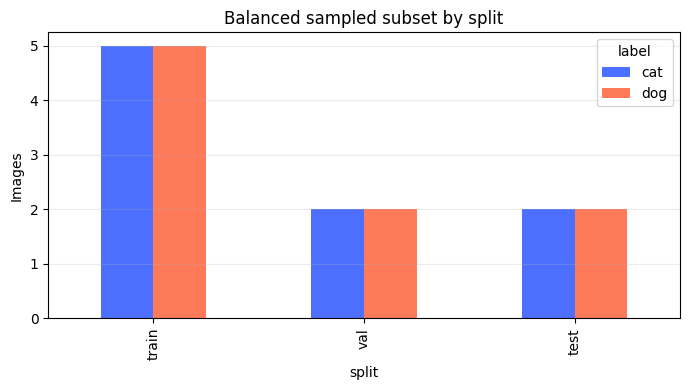

In [44]:
def sample_balanced_by_split_and_label(
    frame: pd.DataFrame, n_per_group: int, seed: int
) -> pd.DataFrame:
    # TODO: sample n_per_group rows from each (split, label) group and return the combined DataFrame.
        sampled_df = (
            frame.groupby(["split", "label"], group_keys=True)
            .apply(lambda x: x.sample(n=min(len(x), n_per_group), random_state=seed))
        )
        for col in ["split", "label"]:
            sampled_df = sampled_df.reset_index(level=col, drop=False)
        return sampled_df.reset_index(drop=True)

sample_size_per_group = 5
sampled_df = sample_balanced_by_split_and_label(
    analysis_df, n_per_group=sample_size_per_group, seed=SEED
)
print("sampled shape:", sampled_df.shape)
display(sampled_df.head())

sampled_balance = sampled_df.groupby(["split", "label"]).size().unstack(fill_value=0)
display(sampled_balance)
 
plot_class_balance(sampled_df, title="Balanced sampled subset by split")

## Reflection

Try writing short answers to these questions. These are meant for self-study only and will not be graded:

1. What are some other commonly used train-validation-test splits in practice?
- They are 70-15-15 or 80-10-10. But if in my project, I think I will do 90-5-5.
2. What should we do when the dataset is small, like in this lab? Should we still follow the standard train-validation-test split?
- When can split the data into many parts, then train them many times. We can follow the standard but I think it will not be good enough
3. Why is grouped sampling useful before training a model?
- Because when we group, we can see the difference between every single parts. Like if you put 10 dog pictures with 1 cat picture together. The model will automatically define it as dog.
4. Which Pandas operation felt most useful in this lab: `groupby`, `value_counts`, `qcut`, or sampling within groups? Why?
- I would prefer groupby, because we can split the dataset into separated equal parts like in the exercise 8, the model can do well to differentia pictures
